<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/%EB%AF%B8%EB%8B%88%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EC%A0%9C%EC%B6%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YB 1조 미니 프로젝트(1)
- 과제 : 지금가지 배운 파이썬 기초와 시각화 코드를 통해 10개 이상의 그래프를 그리고, 유의미한 결과 도출하기 (데이터 전처리는 예시 참고)
- https://dacon.io/competitions/open/235536/data
- 위의 링크에서 train.csv 파일을 다운받고 사이트를 참고하여 새로 알고자 하는 내용으로 데이터를 분석하기.
- 조건 : 변수 2개 이상 연결하기

## **0. 주로 사용하는 library import**


In [1]:
# matplotlib 한글 깨짐방지
# 아래코드 실행후 '런타임 다시시작' 후 모듈 불러오기
# 참고 블로그: https://teddylee777.github.io/colab/colab-korean
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,752 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') #matplotlib 한글 깨짐 방지

import warnings
warnings.filterwarnings(action='ignore')

In [4]:
train=pd.read_csv("/content/movies_train.csv")

## **1. 탐색적 자료분석(EDA)**

### (1) 데이터 설명

2010년대 한국에서 개봉한 한국영화 600개에 대한 감독, 이름, 상영등급, 관객수 등의 정보가 담긴 데이터

### (2) 변수 확인
- title : 영화의 제목
- distributor : 배급사
- genre : 장르
- release_time : 개봉일
- time : 상영시간(분)
- screening_rat : 상영등급
- director : 감독이름
- dir_prev_bfnum : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(단 관객수가 알려지지 않은 영화 제외)
- dir_prev_num : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수(단 관객수가 알려지지 않은 영화 제외)
- num_staff : 스텝수
- num_actor : 주연배우수
- box_off_num : 관객수

### (3) 데이터 요약

In [11]:
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,0.00,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [12]:
train.tail()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.0,1,510,7,1475091
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.0,1,286,6,1716438
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,0.0,0,123,4,2475
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,0.0,0,431,4,2192525
599,베를린,CJ 엔터테인먼트,액션,2013-01-30,120,15세 관람가,류승완,0.0,0,363,5,7166532


In [14]:
print(train.shape)

(600, 12)


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           600 non-null    object        
 1   distributor     600 non-null    object        
 2   genre           600 non-null    object        
 3   release_time    600 non-null    datetime64[ns]
 4   time            600 non-null    int64         
 5   screening_rat   600 non-null    object        
 6   director        600 non-null    object        
 7   dir_prev_bfnum  600 non-null    float64       
 8   dir_prev_num    600 non-null    int64         
 9   num_staff       600 non-null    int64         
 10  num_actor       600 non-null    int64         
 11  box_off_num     600 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 56.4+ KB


-> 총 12개의 변수와 600개의 데이터가 존재함

### (4) 결측치 확인 및 데이터 전처리

In [5]:
train.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [6]:
# 결측값의 특성 확인
train[train['dir_prev_bfnum'].isna()].head(3)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
6,길위에서,백두대간,다큐멘터리,2013-05-23,104,전체 관람가,이창재,NaN,0,32,5,53526
8,"1789, 바스티유의 연인들",유니버설픽쳐스인터내셔널코리아,뮤지컬,2014-09-18,129,전체 관람가,정성복,NaN,0,3,5,4778


In [7]:
print(train[train['dir_prev_bfnum'].isna()]['dir_prev_num'].sum())

0


- 변수 'dir_prev_bfnum'에 330개의 결측값이 존재한다.
- 결측값은 NaN으로 저장되어 있다.
- 이는 감독의 이전작품이 존재 하지 않은 경우이다. 따라서 dir_prev_bfnum에 있는 결측값은 전부 0으로 채운다.

In [16]:
train['dir_prev_bfnum'].fillna(0, inplace=True)

- release_time은 시간에 관련된 데이터인데 int형으로 인식되고 있다. release_time을 datetime형식으로 변환한다.

In [17]:
train['release_time']=pd.to_datetime(train['release_time'])

## **3. 데이터 시각화 및 분석**

###산점도(Scatterplot)

In [ ]:
# 상관계수
train[['time', 'dir_prev_bfnum', 'dir_prev_num', 'num_staff', 'num_actor', 'box_off_num']].corr()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
time,1.000000,0.266065,0.306727,0.623205,0.114153,0.441452
dir_prev_bfnum,0.266065,1.000000,0.396616,0.369657,0.042491,0.293791
dir_prev_num,0.306727,0.396616,1.000000,0.450706,0.014006,0.259674
num_staff,0.623205,0.369657,0.450706,1.000000,0.077871,0.544265
num_actor,0.114153,0.042491,0.014006,0.077871,1.000000,0.111179
box_off_num,0.441452,0.293791,0.259674,0.544265,0.111179,1.000000


- 스태프 수와 관객 수의 산점도를 분석한 결과, 양의 상관관계를 확인했습니다. 스태프 수가 일정 규모(약 300명 이상) 투입된 작품들이 히트를 기록하는 경향을 보였습니다. 대규모 인력 투입이 무조건적인 흥행을 보장하는 것은 아니지만, 폭발적인 관객 동원을 이끌어내기 위해서는 일정 수준 이상의 자본과 규모가 필수적인 요소임을 알 수 있습니다.

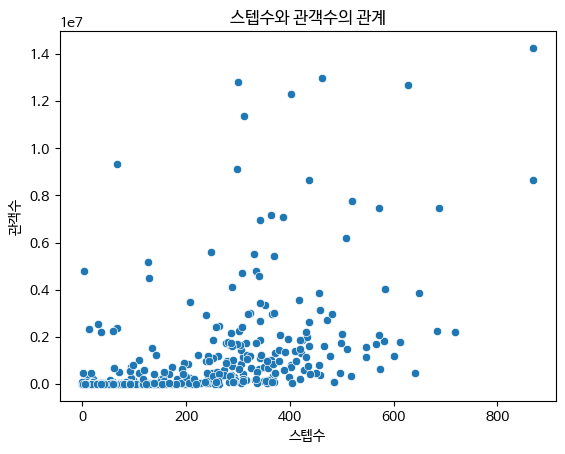

In [ ]:
# 산점도1: 스텝수 vs 관객수
sns.scatterplot(x='num_staff', y='box_off_num', data=train)
plt.title('스텝수와 관객수의 관계')
plt.xlabel('스텝수')
plt.ylabel('관객수')
plt.show()

- 상영 시간과 관객 수의 분포를 살펴보면, 크게 흥행한 상업 영화들이 110분에서 130분 구간에 군집을 이루고 있는 것을 확인할 수 있습니다. 반면 90분 이하이거나 140분을 초과하는 영화는 상대적으로 관객 동원력의 한계치가 낮게 형성되었습니다. 이는 관객의 몰입도를 극대화하고 상업적 성공을 거두기 위한 최적의 러닝타임 구간이 존재함을 시사합니다.

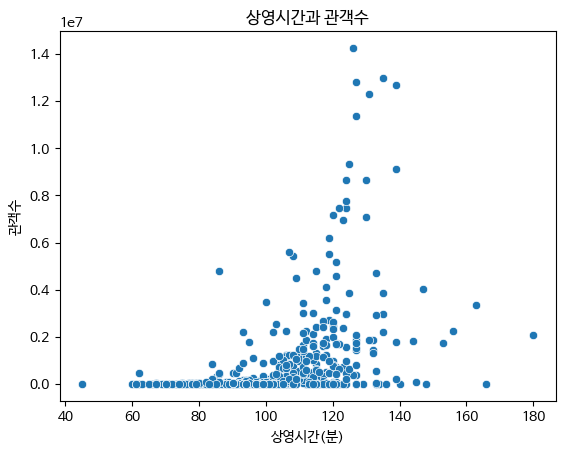

In [ ]:
# 산점도2: 상영시간 vs 관객수
sns.scatterplot(x='time', y='box_off_num', data=train)
plt.title('상영시간과 관객수')
plt.xlabel('상영시간(분)')
plt.ylabel('관객수')
plt.show()

- 감독의 이전 평균 관객 수와 신작의 관객 수를 비교한 결과, 뚜렷한 선형 관계가 나타나지 않았습니다. 전작이 크게 성공했음에도 신작의 흥행이 부진한 경우가 존재하며, 반대로 이전 성적이 낮거나 신인 감독임에도 대중적인 성공을 거둔 '언더독' 사례가 다수 발견되었습니다. 따라서 감독의 과거 흥행 지표 단일 요인만으로 신작의 흥행을 예측하는 데에는 뚜렷한 한계가 있습니다.

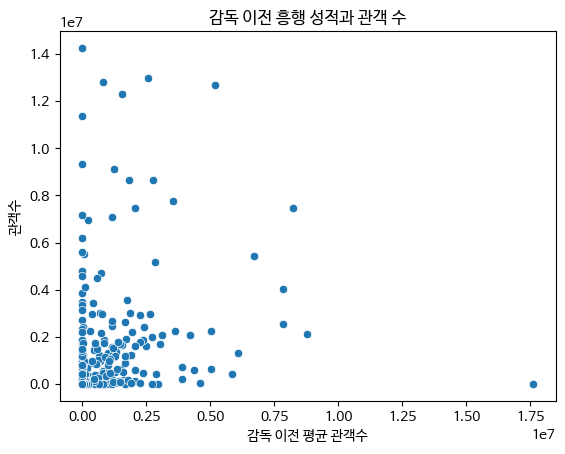

In [ ]:
# 산점도3: 감독 이전 흥행 성적 vs 관객 수
sns.scatterplot(x='dir_prev_bfnum', y='box_off_num', data=train)
plt.title('감독 이전 흥행 성적과 관객 수')
plt.xlabel('감독 이전 평균 관객수')
plt.ylabel('관객수')
plt.show()

###바플롯(Barplot)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')        # 폰트 설치 및 적용
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=font_path)
plt.rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
!apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train1 = pd.read_csv('/content/drive/MyDrive/ESAA/movies_train.csv')
print(train1.head())

       title   distributor genre release_time  time screening_rat director  \
0     개들의 전쟁      롯데엔터테인먼트    액션   2012-11-22    96      청소년 관람불가      조병옥   
1       내부자들        (주)쇼박스   느와르   2015-11-19   130      청소년 관람불가      우민호   
2  은밀하게 위대하게        (주)쇼박스    액션   2013-06-05   123       15세 관람가      장철수   
3   나는 공무원이다        (주)NEW   코미디   2012-07-12   101        전체 관람가      구자홍   
4       불량남녀  쇼박스(주)미디어플렉스   코미디   2010-11-04   108       15세 관람가      신근호   

   dir_prev_bfnum  dir_prev_num  num_staff  num_actor  box_off_num  
0             NaN             0         91          2        23398  
1      1161602.50             2        387          3      7072501  
2       220775.25             4        343          4      6959083  
3        23894.00             2         20          6       217866  
4            1.00             1        251          2       483387  


In [ ]:
# 장르 종류 및 해당 장르의 상영 영화 수
genre_df =train1['genre'].value_counts().reset_index()
genre_df.columns = ['genre', 'count']
print(genre_df)

     genre  count
0      드라마    221
1    다큐멘터리     93
2   멜로/로맨스     78
3      코미디     53
4       공포     42
5       액션     28
6      느와르     27
7    애니메이션     21
8     미스터리     17
9       SF     13
10     뮤지컬      5
11    서스펜스      2


- 이 그래프는 x축에 장르 종류, y축에 영화 수로 각 장르별로 얼마나 많은 영화가 상영되었는지를 보여주는 바플롯입니다. 드라마 장르 영화가 2위인 다큐멘터리보다 두배 이상 많은 수치로 압도적으로 많이 상영됐습니다.그 다음으로 다큐멘터리, 멜로/로멘스 순으로 높은 비중을 차지하고 있으며 액션과 느와르 같은 특정장르는 상영 영화 수가 매우 적게 나타납니다. 이는 영화 시장이 특정 장르 중심으로 편중됐음을 시사합니다.

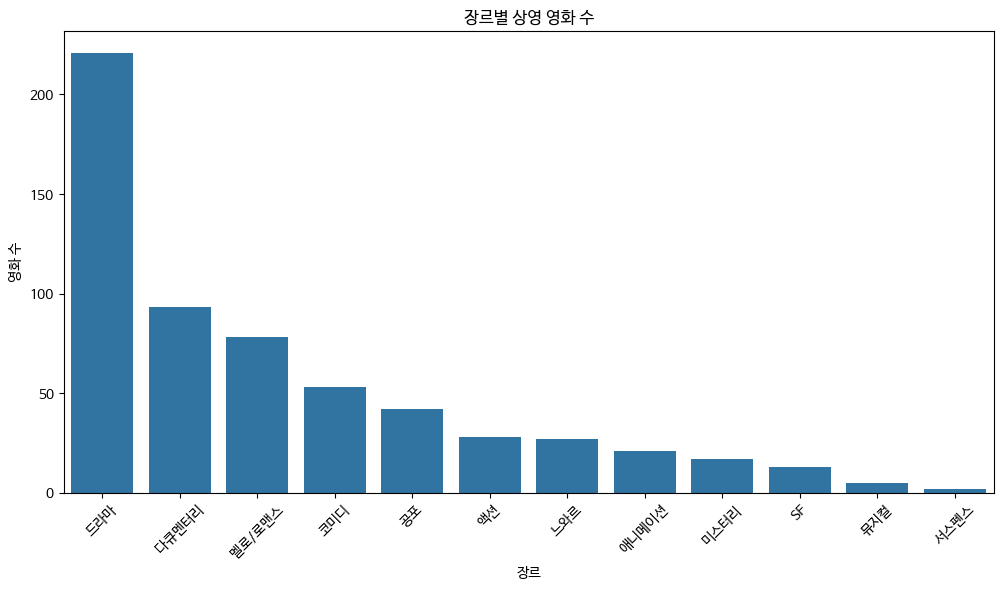

In [ ]:
# 바플롯1: 장르별 상영 영화 수
plt.figure(figsize=(12,6))
sns.barplot(x='genre', y='count', data=genre_df)
plt.xticks(rotation=45)
plt.xlabel('장르')
plt.ylabel('영화 수')
plt.title('장르별 상영 영화 수')
plt.show()

In [ ]:
screening_rat_mean = train1.groupby('screening_rat')['box_off_num'].mean().round(2).reset_index()
print(screening_rat_mean)

  screening_rat  box_off_num
0       12세 관람가    844980.90
1       15세 관람가   1247518.64
2        전체 관람가    135100.46
3      청소년 관람불가    364181.33


- 이 그래프는 x축은 상영등금, y축은 평균관객수로 상영등급별 평균 관객 수를 비교한 바플롯입니다. 15세 관람가 영화가 가장 높은 평균 관객 수를 기록했으며 접근성과 대중성의 균형이 잘 맞는 등급으로 해석할 수 있습니다. 전체관람가 등급은 평균 관객 수가 가장 낮았으며 접근성이 높은 반면 흥행 규모는 낮은 경우가 많음을 알 수 있습니다.
청소년 관람불가는 12세와 15세 관람가에 비해 낮으나 전체 관람가 보다 약 2배 높은 평균 관객 수를 보이며 관객층은 가장 제한되어있음에도 어느정도의 흥행은 유지하는 것으로 보입니다.

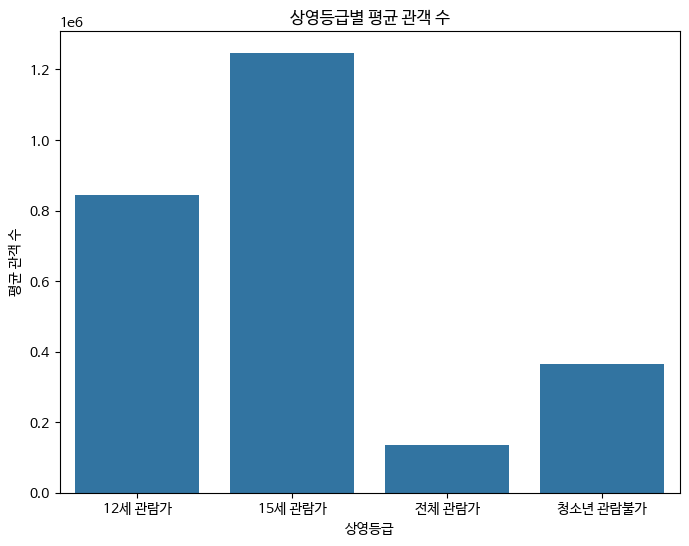

In [ ]:
# 바플롯2: 상영등급별 평균 관객 수
plt.figure(figsize=(8,6))
sns.barplot(x='screening_rat', y='box_off_num', data=screening_rat_mean)
plt.xlabel('상영등급')
plt.ylabel('평균 관객 수')
plt.title('상영등급별 평균 관객 수')
plt.show()

### 히스토그램

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') #matplotlib 한글 깨짐 방지

import warnings
warnings.filterwarnings(action='ignore')
from google.colab import files
uploaded = files.upload()

import pandas as pd
train2 = pd.read_csv("movies_train.csv")

Saving movies_train.csv to movies_train (3).csv


이 히스토그램은 영화별 상영시간의 분포를 나타냅니다. x축은 영화의 상영시간(분), y축은 해당 상영시간 구간에 속하는 영화의 개수를 나타냅니다. 전체적으로 상영시간은 약 80분에서 120분 사이에 가장 많이 분포되어 있으며, 특히 90~110분 구간에 영화가 집중되어 있는 것을 확인할 수 있습니다. 반면 60분 이하나 140분 이상의 극단적인 상영시간을 가진 영화는 상대적으로 적게 나타납니다. 이는 대부분의 영화가 관객의 집중도와 상업성을 고려하여 약 100분 내외의 상영시간으로 제작되는 경향이 있음을 보여줍니다.

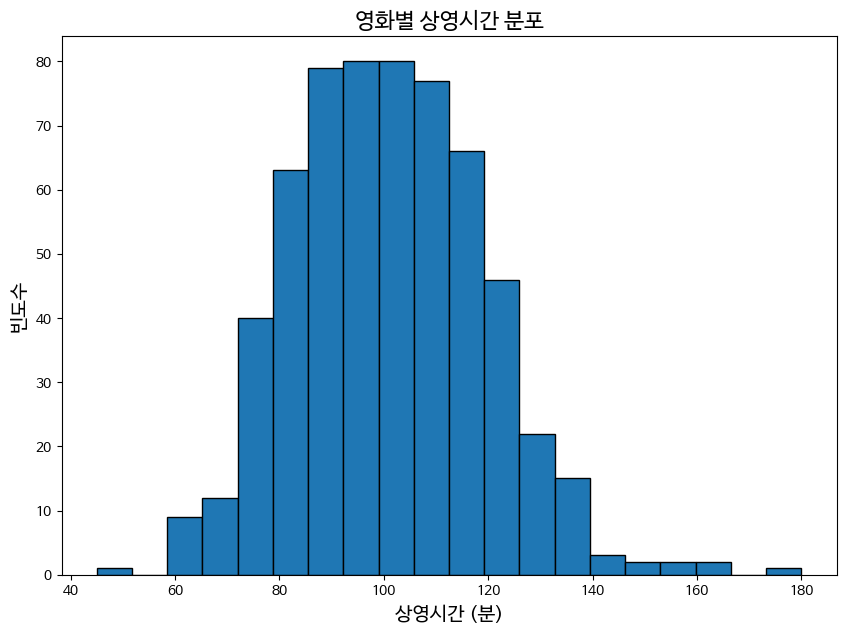

In [ ]:
plt.figure(figsize=(10,7))

plt.hist(train2['time'].dropna(), bins=20, edgecolor='black')

plt.xlabel('상영시간 (분)', fontsize=14)
plt.ylabel('빈도수', fontsize=14)
plt.title('영화별 상영시간 분포', fontsize=16)

plt.show()

이 히스토그램은 영화별 스태프 분포를 보여주는 히스토그램입니다. x축은 영화 제작에 참여한 스태프 수, y축은 해당 구간에 속하는 영화의 개수를 나타냅니다. 그래프를 보면 스태프 수가 적은 영화들이 많이 분포되어 있으며, 특히 0~100명 구간에 영화가 집중되어 있습니다. 반면 스태프 수가 많아질수록 해당하는 영화 수는 점점 감소하는 오른쪽 꼬리가 긴 형태(우측 편향)를 보입니다. 일부 영화는 매우 많은 스태프를 보유하고 있지만 이는 소수에 불과하며, 전반적으로 대부분의 영화는 비교적 적은 규모의 제작 인력으로 만들어진다는 점을 확인할 수 있습니다.

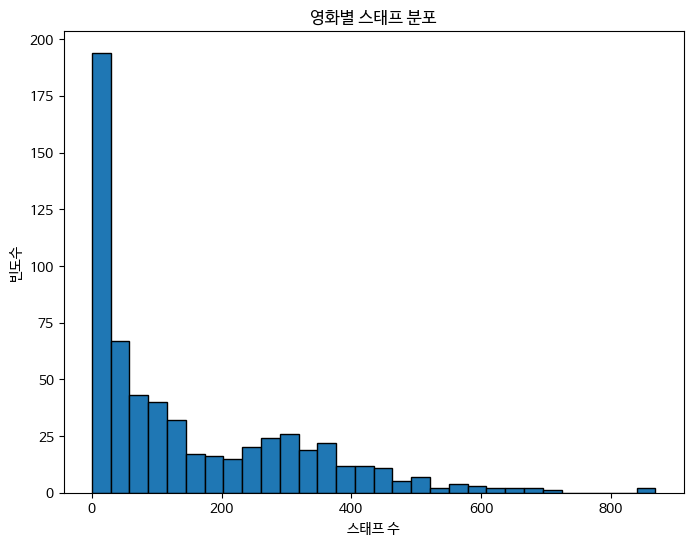

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(train2['num_staff'].dropna(), bins=30, edgecolor='black')

plt.xlabel('스태프 수')
plt.ylabel('빈도수')
plt.title('영화별 스태프 분포')

plt.show()

### 바이올린 플롯